# Step-by-Step Tutorial: Random Forest with ID3-Style Information Gain

This notebook introduces the **Random Forest** classification model, with a focus on **ID3-style entropy and information gain**.

## Learning objectives

By the end of this tutorial, students should be able to:

1. Explain the basic idea of a decision tree.
2. Explain the ID3 algorithm using entropy and information gain.
3. Calculate entropy and information gain by hand.
4. Understand how a Random Forest combines many decision trees.
5. Train a Random Forest model with `scikit-learn`.
6. Explain important Random Forest hyperparameters.
7. Visualize the effect of tree depth and number of trees.
8. Compare a single decision tree with a Random Forest.
9. Interpret feature importance.
10. Understand the practical difference between ID3 and scikit-learn's tree implementation.

## Important note about ID3 and scikit-learn

Classic **ID3** builds a decision tree using **information gain** based on **Shannon entropy**. It was originally designed mainly for categorical features.

In `scikit-learn`, `DecisionTreeClassifier` and `RandomForestClassifier` use a CART-style tree implementation. However, they support:

```python
criterion="entropy"
```

This uses Shannon information gain to measure split quality.

So in this notebook:

- The theory section explains ID3-style splitting.
- The implementation section uses `RandomForestClassifier(criterion="entropy")`.
- This is not a pure historical ID3 implementation, but it gives students a practical way to connect ID3 concepts to modern Random Forests.

## 1. From one decision tree to Random Forest

A **decision tree** predicts by asking a sequence of questions.

Example:

```text
Is petal length <= 2.45?
    Yes -> class A
    No  -> ask another question
```

A **Random Forest** is an ensemble of many decision trees.

Instead of relying on one tree, Random Forest trains many trees and combines their predictions.

For classification:

$$
\hat{y} = \text{majority vote of all trees}
$$

If 100 trees vote:

- 72 trees vote class 1
- 28 trees vote class 0

Then the forest predicts class 1.

## Why use many trees?

A single decision tree can overfit. It may learn very specific patterns in the training data.

Random Forest reduces overfitting by combining many different trees.

The trees become different because Random Forest uses:

1. **Bootstrap sampling**: each tree sees a random sample of the training data.
2. **Random feature selection**: each split considers only a random subset of features.

This makes the trees less correlated with each other.

## 2. ID3: the basic idea

The ID3 algorithm builds a decision tree top-down.

At each node, ID3 asks:

> Which feature gives the best split?

To answer this, ID3 calculates **information gain**.

The feature with the highest information gain is selected.

## Entropy

Entropy measures impurity or uncertainty.

For binary classification:

$$
H(S) = -p_0 \log_2(p_0) - p_1 \log_2(p_1)
$$

where:

- $p_0$ is the proportion of class 0
- $p_1$ is the proportion of class 1

### Interpretation

| Situation | Entropy |
|---|---:|
| All examples belong to one class | 0 |
| Classes are perfectly mixed, 50%-50% | 1 |
| One class dominates | Between 0 and 1 |

Low entropy means the node is pure.

High entropy means the node is mixed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def entropy_from_counts(counts):
    # Calculate Shannon entropy from class counts.
    counts = np.array(counts, dtype=float)
    total = counts.sum()

    if total == 0:
        return 0.0

    probabilities = counts / total
    probabilities = probabilities[probabilities > 0]

    return -np.sum(probabilities * np.log2(probabilities))


examples = {
    "Pure class 0: [10, 0]": [10, 0],
    "Pure class 1: [0, 10]": [0, 10],
    "Mixed 50-50: [5, 5]": [5, 5],
    "Mostly class 0: [8, 2]": [8, 2],
    "Mostly class 1: [2, 8]": [2, 8]
}

entropy_table = pd.DataFrame({
    "Case": list(examples.keys()),
    "Counts [class 0, class 1]": list(examples.values()),
    "Entropy": [entropy_from_counts(v) for v in examples.values()]
})

entropy_table

,Case,"Counts [class 0, class 1]",Entropy
0,"Pure class 0: [10, 0]","[10, 0]",-0.000000
1,"Pure class 1: [0, 10]","[0, 10]",-0.000000
2,"Mixed 50-50: [5, 5]","[5, 5]",1.000000
3,"Mostly class 0: [8, 2]","[8, 2]",0.721928
4,"Mostly class 1: [2, 8]","[2, 8]",0.721928


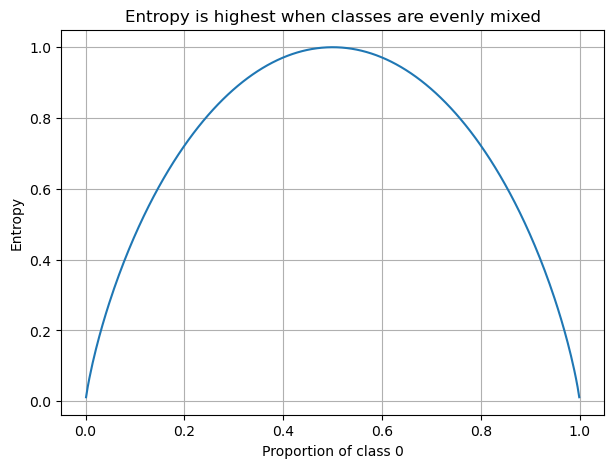

In [2]:
p_values = np.linspace(0.001, 0.999, 300)
entropy_values = [
    entropy_from_counts([p, 1 - p]) for p in p_values
]

plt.figure(figsize=(7, 5))
plt.plot(p_values, entropy_values)
plt.xlabel("Proportion of class 0")
plt.ylabel("Entropy")
plt.title("Entropy is highest when classes are evenly mixed")
plt.grid(True)
plt.show()

## 3. Information Gain

Information gain measures how much a split reduces entropy.

$$
IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|}H(S_v)
$$

where:

- $S$ is the dataset at the current node
- $A$ is a candidate feature
- $v$ is a value or split outcome of feature $A$
- $S_v$ is the subset after splitting by value $v$

In simple words:

$$
\text{Information Gain} = \text{Entropy before split} - \text{Weighted entropy after split}
$$

A good split makes the child nodes more pure.

Therefore, a good split has high information gain.

## 4. Tiny ID3 example by hand

Suppose we want to predict whether a student **passes**.

We use two features:

- `Studied`: Yes or No
- `Slept Well`: Yes or No

Dataset:

| Student | Studied | Slept Well | Pass |
|---|---|---|---|
| 1 | Yes | Yes | Yes |
| 2 | Yes | No | Yes |
| 3 | Yes | Yes | Yes |
| 4 | No | Yes | No |
| 5 | No | No | No |
| 6 | No | Yes | No |

There are:

- 3 Pass = Yes
- 3 Pass = No

So the parent entropy is:

$$
H(S) = -\frac{3}{6}\log_2(\frac{3}{6}) - \frac{3}{6}\log_2(\frac{3}{6})
$$

$$
H(S) = 1
$$

Now we compare the information gain of the two features.

In [3]:
student_data = pd.DataFrame({
    "Student": [1, 2, 3, 4, 5, 6],
    "Studied": ["Yes", "Yes", "Yes", "No", "No", "No"],
    "Slept Well": ["Yes", "No", "Yes", "Yes", "No", "Yes"],
    "Pass": ["Yes", "Yes", "Yes", "No", "No", "No"]
})

student_data

,Student,Studied,Slept Well,Pass
0,1,Yes,Yes,Yes
1,2,Yes,No,Yes
2,3,Yes,Yes,Yes
3,4,No,Yes,No
4,5,No,No,No
5,6,No,Yes,No


In [4]:
def class_counts(series):
    return series.value_counts().sort_index()

def entropy_of_labels(labels):
    counts = labels.value_counts().values
    return entropy_from_counts(counts)

def information_gain_categorical(data, feature, target):
    parent_entropy = entropy_of_labels(data[target])
    total_size = len(data)

    weighted_child_entropy = 0.0

    for value, subset in data.groupby(feature):
        weight = len(subset) / total_size
        child_entropy = entropy_of_labels(subset[target])
        weighted_child_entropy += weight * child_entropy

        print(f"Feature={feature}, value={value}")
        print(f"Subset size: {len(subset)}")
        print("Class counts:")
        print(class_counts(subset[target]))
        print(f"Child entropy: {child_entropy:.3f}")
        print()

    gain = parent_entropy - weighted_child_entropy

    print(f"Parent entropy: {parent_entropy:.3f}")
    print(f"Weighted child entropy: {weighted_child_entropy:.3f}")
    print(f"Information gain for {feature}: {gain:.3f}")

    return gain

gain_studied = information_gain_categorical(student_data, "Studied", "Pass")

Feature=Studied, value=No
Subset size: 3
Class counts:
Pass
No    3
Name: count, dtype: int64
Child entropy: -0.000

Feature=Studied, value=Yes
Subset size: 3
Class counts:
Pass
Yes    3
Name: count, dtype: int64
Child entropy: -0.000

Parent entropy: 1.000
Weighted child entropy: 0.000
Information gain for Studied: 1.000


In [5]:
gain_slept = information_gain_categorical(student_data, "Slept Well", "Pass")

Feature=Slept Well, value=No
Subset size: 2
Class counts:
Pass
No     1
Yes    1
Name: count, dtype: int64
Child entropy: 1.000

Feature=Slept Well, value=Yes
Subset size: 4
Class counts:
Pass
No     2
Yes    2
Name: count, dtype: int64
Child entropy: 1.000

Parent entropy: 1.000
Weighted child entropy: 1.000
Information gain for Slept Well: 0.000


### Interpretation

`Studied` perfectly separates the classes:

- `Studied = Yes` -> all students pass
- `Studied = No` -> all students do not pass

So the child entropy becomes 0.

That gives maximum information gain.

Therefore, ID3 would choose `Studied` as the root split.

## 5. Train a single ID3-style decision tree with scikit-learn

Now we train a single decision tree using:

```python
criterion="entropy"
```

This connects to ID3-style information gain.

We use the Iris dataset because it is simple and easy to visualize.

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
print("Target names:", iris.target_names)
print("Feature names:", list(X.columns))
print("Shape:", X.shape)

Target names: ['setosa' 'versicolor' 'virginica']
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Shape: (150, 4)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

single_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=RANDOM_STATE
)

single_tree.fit(X_train, y_train)

y_pred_tree = single_tree.predict(X_test)

print("Single tree accuracy:", accuracy_score(y_test, y_pred_tree))
print()
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))

Single tree accuracy: 0.9333333333333333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



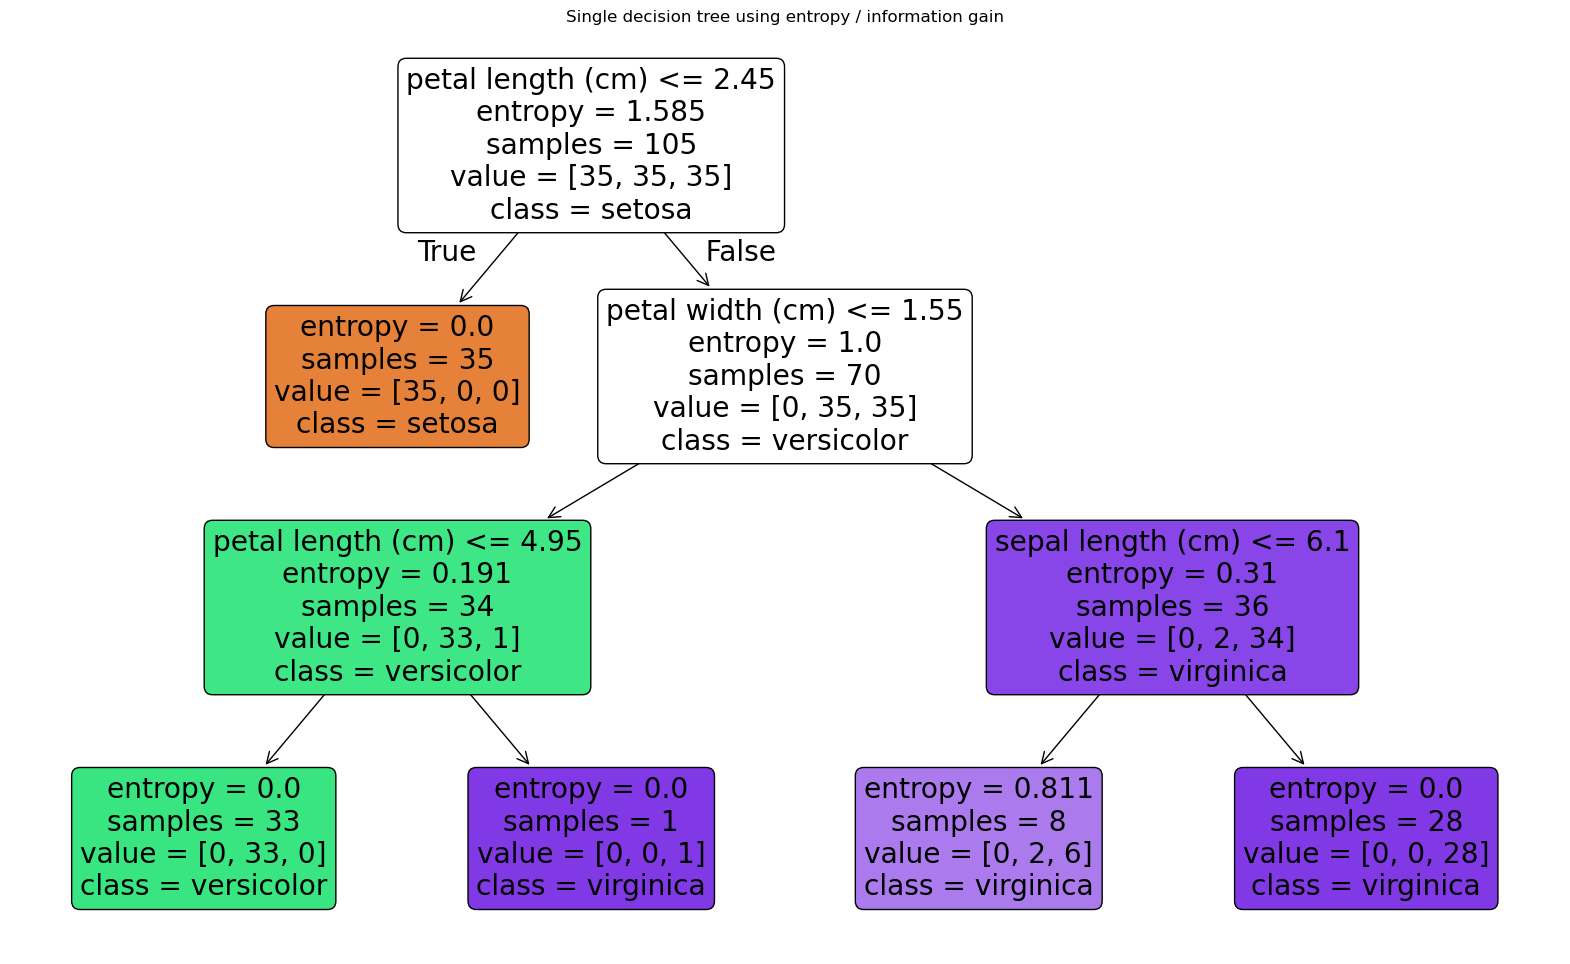

In [12]:
plt.figure(figsize=(20, 12))
plot_tree(
    single_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Single decision tree using entropy / information gain")
plt.show()

## 6. From one tree to Random Forest

A Random Forest trains many decision trees.

Each tree is trained on a bootstrap sample.

A bootstrap sample is created by sampling training examples **with replacement**.

Example:

Original training indices:

```text
[0, 1, 2, 3, 4, 5]
```

One bootstrap sample could be:

```text
[0, 0, 2, 3, 3, 5]
```

Some examples appear multiple times. Some examples are not used.

The examples not used for a tree are called **out-of-bag** examples.

Random Forest also uses random feature subsets at each split.

This increases diversity among trees.

## 7. Train a Random Forest with entropy criterion

Now we train a Random Forest using:

```python
criterion="entropy"
```

Important parameters:

| Parameter | Meaning |
|---|---|
| `n_estimators` | Number of trees |
| `criterion` | Split quality measure; here we use entropy |
| `max_depth` | Maximum depth of each tree |
| `max_features` | Number of features considered at each split |
| `bootstrap` | Whether to use bootstrap samples |
| `oob_score` | Whether to calculate out-of-bag score |
| `random_state` | Makes the result reproducible |

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_depth=None,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print("Out-of-bag score:", rf_model.oob_score_)
print()
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))

Random Forest accuracy: 0.8888888888888888
Out-of-bag score: 0.9523809523809523

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



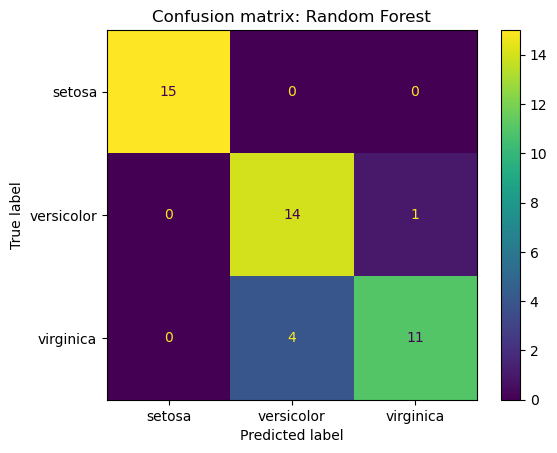

In [14]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("Confusion matrix: Random Forest")
plt.show()

## 8. Compare single tree and Random Forest


In [16]:
comparison = pd.DataFrame({
    "Model": ["Single Decision Tree", "Random Forest"],
    "Test accuracy": [
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Test accuracy
0,Single Decision Tree,0.933333
1,Random Forest,0.888889


## 9. Effect of the number of trees

The parameter `n_estimators` controls how many trees are used.

Usually:

- Too few trees: unstable performance.
- More trees: more stable predictions.
- Very many trees: longer training time, often only small improvement after a point.

Let us test different values.

In [17]:
tree_counts = [1, 5, 10, 25, 50, 100, 200, 500]
tree_count_results = []

for n_trees in tree_counts:
    model = RandomForestClassifier(
        n_estimators=n_trees,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True if n_trees >= 10 else False,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    row = {
        "n_estimators": n_trees,
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": model.score(X_test, y_test)
    }

    if n_trees >= 10:
        row["oob_score"] = model.oob_score_
    else:
        row["oob_score"] = np.nan

    tree_count_results.append(row)

tree_count_df = pd.DataFrame(tree_count_results)
tree_count_df

,n_estimators,train_accuracy,test_accuracy,oob_score
0,1,0.990476,0.844444,NaN
1,5,0.980952,0.911111,NaN
2,10,0.980952,0.911111,0.971429
3,25,1.000000,0.911111,0.952381
4,50,1.000000,0.888889,0.952381
5,100,1.000000,0.888889,0.952381
6,200,1.000000,0.888889,0.952381
7,500,1.000000,0.911111,0.952381


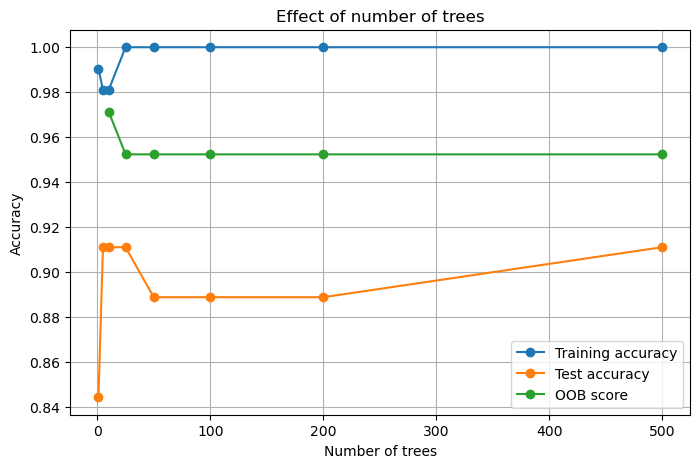

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(tree_count_df["n_estimators"], tree_count_df["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(tree_count_df["n_estimators"], tree_count_df["test_accuracy"], marker="o", label="Test accuracy")
plt.plot(tree_count_df["n_estimators"], tree_count_df["oob_score"], marker="o", label="OOB score")
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.title("Effect of number of trees")
plt.legend()
plt.grid(True)
plt.show()

## 10. Effect of tree depth

The parameter `max_depth` controls how deep each tree can grow.

Small `max_depth`:

- simpler trees
- less overfitting
- may underfit

Large `max_depth` or `None`:

- more complex trees
- can fit training data very well
- Random Forest reduces overfitting by averaging many trees, but very deep trees can still sometimes overfit

In [19]:
depth_values = [1, 2, 3, 4, 5, None]
depth_results = []

for depth in depth_values:
    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_depth=depth,
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    depth_results.append({
        "max_depth": str(depth),
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": model.score(X_test, y_test),
        "oob_score": model.oob_score_
    })

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,train_accuracy,test_accuracy,oob_score
0,1,0.971429,0.888889,0.895238
1,2,0.971429,0.911111,0.961905
2,3,0.971429,0.911111,0.952381
3,4,1.000000,0.888889,0.952381
4,5,1.000000,0.888889,0.952381
5,None,1.000000,0.888889,0.952381


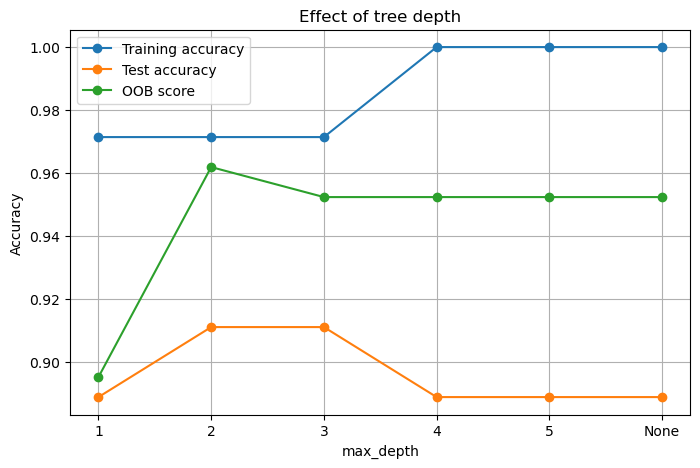

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(depth_df["max_depth"], depth_df["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(depth_df["max_depth"], depth_df["test_accuracy"], marker="o", label="Test accuracy")
plt.plot(depth_df["max_depth"], depth_df["oob_score"], marker="o", label="OOB score")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of tree depth")
plt.legend()
plt.grid(True)
plt.show()

## 11. Feature importance

Random Forest can estimate feature importance.

The built-in feature importance is based on impurity reduction.

In this notebook, because we use `criterion="entropy"`, the built-in importance is related to entropy/information-gain reductions across the forest.

However, built-in impurity importance can be biased, especially toward continuous features or high-cardinality features.

A useful alternative is **permutation importance**.

Permutation importance asks:

> How much does model performance decrease if we randomly shuffle one feature?

If shuffling a feature strongly decreases performance, that feature is important.

In [21]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "impurity_importance": rf_model.feature_importances_
}).sort_values("impurity_importance", ascending=False)

importance_df

,feature,impurity_importance
3,petal width (cm),0.444377
2,petal length (cm),0.409877
0,sepal length (cm),0.121622
1,sepal width (cm),0.024124


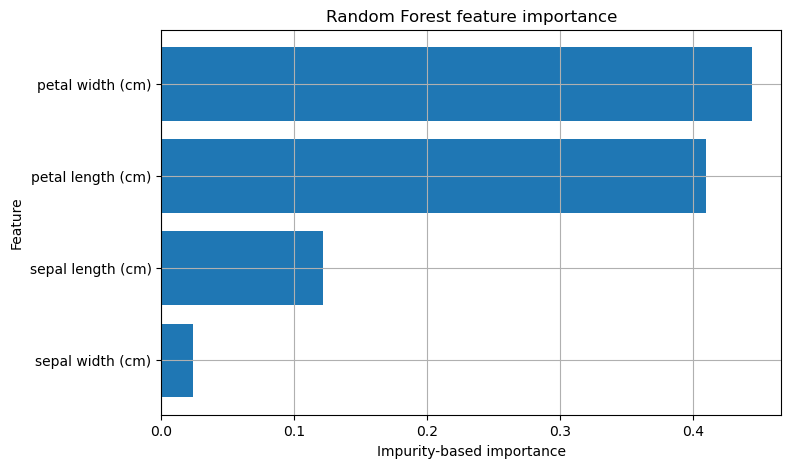

In [22]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["impurity_importance"])
plt.xlabel("Impurity-based importance")
plt.ylabel("Feature")
plt.title("Random Forest feature importance")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

In [23]:
perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "permutation_importance_mean": perm_result.importances_mean,
    "permutation_importance_std": perm_result.importances_std
}).sort_values("permutation_importance_mean", ascending=False)

perm_df

,feature,permutation_importance_mean,permutation_importance_std
2,petal length (cm),0.160741,0.040034
3,petal width (cm),0.137037,0.033985
1,sepal width (cm),-0.002963,0.007554
0,sepal length (cm),-0.018519,0.014152


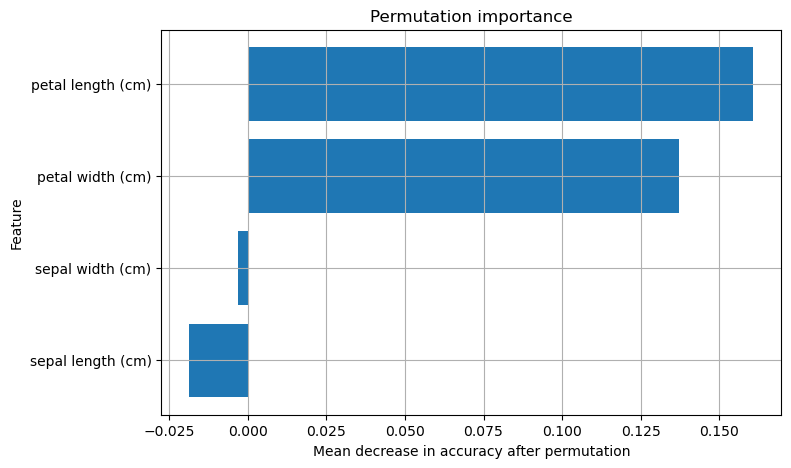

In [24]:
plt.figure(figsize=(8, 5))
plt.barh(perm_df["feature"], perm_df["permutation_importance_mean"])
plt.xlabel("Mean decrease in accuracy after permutation")
plt.ylabel("Feature")
plt.title("Permutation importance")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 12. Hyperparameter tuning with GridSearchCV

Important Random Forest hyperparameters:

| Hyperparameter | Meaning |
|---|---|
| `n_estimators` | Number of trees |
| `max_depth` | Maximum depth of each tree |
| `max_features` | Number of candidate features at each split |
| `min_samples_leaf` | Minimum number of samples in a leaf node |
| `criterion` | Split quality measure |

We tune a small grid for demonstration.

For larger datasets, the grid can become expensive.

In [25]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, None],
    "max_features": ["sqrt", None],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["entropy"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        bootstrap=True,
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print()
print("Best cross-validation accuracy:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
print("Final test accuracy:", best_rf.score(X_test, y_test))

Best parameters:
{'criterion': 'entropy', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}

Best cross-validation accuracy: 0.9619047619047618
Final test accuracy: 0.9111111111111111


In [26]:
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results[[
    "param_n_estimators",
    "param_max_depth",
    "param_max_features",
    "param_min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_n_estimators,param_max_depth,param_max_features,param_min_samples_leaf,mean_test_score,std_test_score,rank_test_score
1,100,2,sqrt,1,0.961905,0.035635,1
2,200,2,sqrt,1,0.961905,0.035635,1
5,200,2,sqrt,2,0.961905,0.035635,1
4,100,2,sqrt,2,0.961905,0.035635,1
7,100,2,sqrt,4,0.961905,0.035635,1
8,200,2,sqrt,4,0.961905,0.035635,1
18,50,3,sqrt,1,0.961905,0.035635,1
26,200,3,sqrt,4,0.961905,0.035635,1
24,50,3,sqrt,4,0.961905,0.035635,1
25,100,3,sqrt,4,0.961905,0.035635,1


## 13. Visualize decision boundaries on a 2D dataset

The Iris dataset has four features, so it is not easy to visualize the boundary.

For visualization, we train on only two features:

- petal length
- petal width

This is only for demonstration.

In [27]:
X_2d = X[["petal length (cm)", "petal width (cm)"]]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

tree_2d = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=RANDOM_STATE
)

rf_2d = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    random_state=RANDOM_STATE
)

tree_2d.fit(X_train_2d, y_train_2d)
rf_2d.fit(X_train_2d, y_train_2d)

print("2D single tree accuracy:", tree_2d.score(X_test_2d, y_test_2d))
print("2D random forest accuracy:", rf_2d.score(X_test_2d, y_test_2d))

2D single tree accuracy: 0.9333333333333333
2D random forest accuracy: 0.9555555555555556


In [28]:
def plot_decision_boundary_2d(model, X_df, y_series, title):
    x_min, x_max = X_df.iloc[:, 0].min() - 0.5, X_df.iloc[:, 0].max() + 0.5
    y_min, y_max = X_df.iloc[:, 1].min() - 0.5, X_df.iloc[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = pd.DataFrame(
        np.c_[xx.ravel(), yy.ravel()],
        columns=X_df.columns
    )

    predictions = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, predictions, alpha=0.25)
    plt.scatter(
        X_df.iloc[:, 0],
        X_df.iloc[:, 1],
        c=y_series,
        edgecolor="black",
        alpha=0.8
    )
    plt.xlabel(X_df.columns[0])
    plt.ylabel(X_df.columns[1])
    plt.title(title)
    plt.grid(True)
    plt.show()

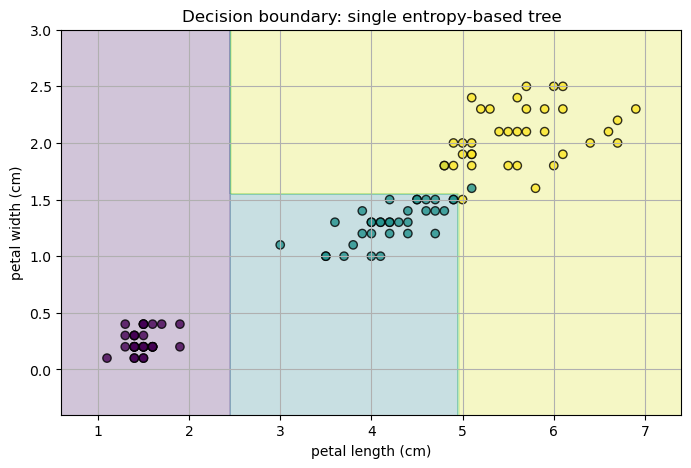

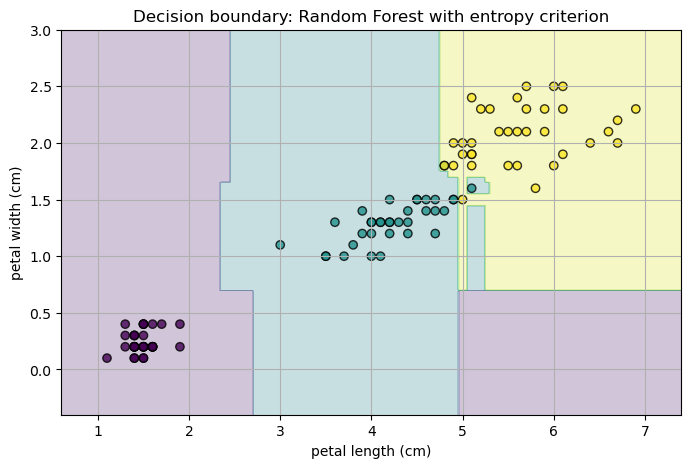

In [29]:
plot_decision_boundary_2d(
    tree_2d,
    X_train_2d,
    y_train_2d,
    "Decision boundary: single entropy-based tree"
)

plot_decision_boundary_2d(
    rf_2d,
    X_train_2d,
    y_train_2d,
    "Decision boundary: Random Forest with entropy criterion"
)

## 14. Practical interpretation

Random Forest is often a strong baseline model because:

1. It handles nonlinear relationships.
2. It usually works well without heavy feature engineering.
3. It can handle mixed feature scales better than distance-based models.
4. It is less sensitive to outliers than many linear models.
5. It gives useful feature importance estimates.

However, Random Forest also has limitations:

1. It is less interpretable than a single decision tree.
2. Large forests can be computationally expensive.
3. It may not extrapolate well beyond the training data.
4. Built-in feature importance can be misleading.
5. It can struggle with very high-dimensional sparse data compared with linear models.

## 15. Summary

In this notebook, we learned:

1. ID3 builds decision trees using entropy and information gain.
2. Entropy measures class impurity.
3. Information gain measures entropy reduction after a split.
4. A single decision tree can overfit.
5. Random Forest combines many trees using majority voting.
6. Random Forest uses bootstrap samples and random feature subsets.
7. `criterion="entropy"` connects Random Forest training to ID3-style information gain.
8. `n_estimators`, `max_depth`, `max_features`, and `min_samples_leaf` are important hyperparameters.
9. Out-of-bag score can estimate generalization performance.
10. Feature importance should be interpreted carefully.

## Recommended student tasks

1. Change `criterion="entropy"` to `criterion="gini"` and compare results.
2. Increase and decrease `n_estimators`.
3. Change `max_depth` and observe overfitting/underfitting.
4. Change `max_features`.
5. Compare a single decision tree and Random Forest on another dataset.
6. Use permutation importance and compare it with built-in impurity importance.
7. Try Random Forest on a dataset from Kaggle or HuggingFace.

## References and further learning

- scikit-learn documentation: `DecisionTreeClassifier`
- scikit-learn documentation: `RandomForestClassifier`
- scikit-learn user guide: decision trees
- scikit-learn user guide: ensemble methods
- Original ID3 idea: decision tree learning with entropy and information gain